In [2]:
import re

In [1]:
# helper function 1 - parse the headers
def parse_prodigal_headers(file_path):
    " Parse a Prodigal output file and return a dictionary mapping protein names to [left_coord, right_coord, strand]."
    protein_dict = {}

    with open(file_path, 'r') as file:
        for line in file:
            line = line.strip()
            if line.startswith(">"): # header line
                parts = line.split("#")
                protein_name = parts[0][1:].strip() # remove leading '>'
                left = int(parts[1].strip())
                right = int(parts[2].strip())
                strand = int(parts[3].strip())
                protein_dict[protein_name] = [left, right, strand]
    return protein_dict

In [3]:
# test:
file_path = "../data/genomes/ecoli_genome.fna.faa"
protein_info = parse_prodigal_headers(file_path)

for protein, coords in protein_info.items():
    print(protein, coords)

NC_000913.3_1 [3, 98, 1]
NC_000913.3_2 [337, 2799, 1]
NC_000913.3_3 [2801, 3733, 1]
NC_000913.3_4 [3734, 5020, 1]
NC_000913.3_5 [5234, 5530, 1]
NC_000913.3_6 [5683, 6459, -1]
NC_000913.3_7 [6529, 7959, -1]
NC_000913.3_8 [8238, 9191, 1]
NC_000913.3_9 [9306, 9893, 1]
NC_000913.3_10 [9928, 10494, -1]
NC_000913.3_11 [10643, 11356, -1]
NC_000913.3_12 [11382, 11786, -1]
NC_000913.3_13 [12163, 14079, 1]
NC_000913.3_14 [14168, 15298, 1]
NC_000913.3_15 [15445, 16557, 1]
NC_000913.3_16 [16580, 16720, 1]
NC_000913.3_17 [16751, 16903, -1]
NC_000913.3_18 [17489, 18655, 1]
NC_000913.3_19 [18721, 19620, 1]
NC_000913.3_20 [19811, 20188, -1]
NC_000913.3_21 [20233, 20508, -1]
NC_000913.3_22 [20815, 21078, -1]
NC_000913.3_23 [21407, 22348, 1]
NC_000913.3_24 [22391, 25207, 1]
NC_000913.3_25 [25207, 25701, 1]
NC_000913.3_26 [25826, 26275, 1]
NC_000913.3_27 [26277, 27227, 1]
NC_000913.3_28 [27293, 28207, 1]
NC_000913.3_29 [28374, 29195, 1]
NC_000913.3_30 [29651, 30799, 1]
NC_000913.3_31 [30817, 34038, 1]
NC

In [10]:
import os
print(os.getcwd())

/stor/work/Marcotte/project/ivyfan/operon-graph/notebooks


In [4]:
# helper function 1 - parse the headers
def parse_prodigal_headers_dict(file_path):
    genes = []
    with open(file_path, 'r') as f:
        for line in f:
            line = line.strip()
            if line.startswith('>'):
                parts = [p.strip() for p in line.split('#')]
                
                # orf_id
                orf_id = parts[0].split()[0][1:]
                
                # contig: orf_id but the last underscore and number
                contig = re.sub(r'_\d+$', '', orf_id)

                start = int(parts[1])
                end = int(parts[2])
                strand = '+' if parts[3].strip() == '1' else '-'
                
                genes.append({
                    "orf_id": orf_id,
                    "contig": contig,
                    "start": min(start, end),
                    "end": max(start, end),
                    "strand": strand
                })
    return genes

In [5]:
# helper function 2 - find distance between two genes on the same strand
def gene_distance(gene1, gene2):
    # return None if they are not on the same contig or strand
    if gene1["contig"] != gene2["contig"]:
        return None
    if gene1["strand"] != gene2["strand"]:
        return None
    
    # sort by start position
    g1, g2 = sorted([gene1, gene2], key=lambda g: g['start'])
    
    #calculate distance
    distance = g2['start'] - g1['end']
    
    return distance

In [6]:
# helper function 3 - group the genes that are close enough to be on the same operon
def group_operons(genes, max_distance=200):
    # sort the genes based on contig, strand, and start position
    genes = sorted(genes, key=lambda g: (g["contig"], g["strand"], g["start"]))
    operons = []
    current_operon = [genes[0]]
    
    for g in genes[1:]:
        last_gene = current_operon[-1]
        dist = gene_distance(last_gene, g)
        
        if dist is not None and dist <= max_distance:
            # put in the same operon
            current_operon.append(g)
        else:
            # different operon, start a new operon group
            operons.append(current_operon)
            current_operon = [g]
            
    operons.append(current_operon)
    return operons

In [8]:
# shows operon group output
file_path = "../data/genomes/ecoli_genome.fna.faa"

# parse genes
genes = parse_prodigal_headers_dict(file_path)

# group into operons
operons = group_operons(genes, max_distance=200)

for i, operon in enumerate(operons, 1):
    ids = [g["orf_id"] for g in operon]
    strand = operon[0]["strand"]
    start = operon[0]["start"]
    end = operon[-1]["end"]
    print(f"Operon {i}: genes {ids} (strand {strand}, range {start}-{end})")

Operon 1: genes ['NC_000913.3_1'] (strand +, range 3-98)
Operon 2: genes ['NC_000913.3_2', 'NC_000913.3_3', 'NC_000913.3_4'] (strand +, range 337-5020)
Operon 3: genes ['NC_000913.3_5'] (strand +, range 5234-5530)
Operon 4: genes ['NC_000913.3_8', 'NC_000913.3_9'] (strand +, range 8238-9893)
Operon 5: genes ['NC_000913.3_13', 'NC_000913.3_14', 'NC_000913.3_15', 'NC_000913.3_16'] (strand +, range 12163-16720)
Operon 6: genes ['NC_000913.3_18', 'NC_000913.3_19'] (strand +, range 17489-19620)
Operon 7: genes ['NC_000913.3_23', 'NC_000913.3_24', 'NC_000913.3_25', 'NC_000913.3_26', 'NC_000913.3_27', 'NC_000913.3_28', 'NC_000913.3_29'] (strand +, range 21407-29195)
Operon 8: genes ['NC_000913.3_30', 'NC_000913.3_31'] (strand +, range 29651-34038)
Operon 9: genes ['NC_000913.3_32'] (strand +, range 34300-34695)
Operon 10: genes ['NC_000913.3_39', 'NC_000913.3_40', 'NC_000913.3_41', 'NC_000913.3_42', 'NC_000913.3_43', 'NC_000913.3_44', 'NC_000913.3_45', 'NC_000913.3_46'] (strand +, range 42403

In [7]:
import networkx as nx

def build_operon_graph(genes, max_distance=200):

    # add nodes to graph
    G = nx.Graph()
    for gene in genes:
        G.add_node(gene['orf_id'], **gene)

    # add edges between neighboring genes on same strand and contig
    genes.sort(key=lambda g: (g['contig'], g['strand'], g['start']))
    for i, g1 in enumerate(genes):
        for j in range(i+1, len(genes)):
            g2 = genes[j]
            if g2['contig'] != g1['contig']:
                break
            if g2['strand'] != g1['strand']:
                continue
            if gene_distance(g1, g2) > max_distance:
                break
            G.add_edge(g1['orf_id'], g2['orf_id'])

    return G

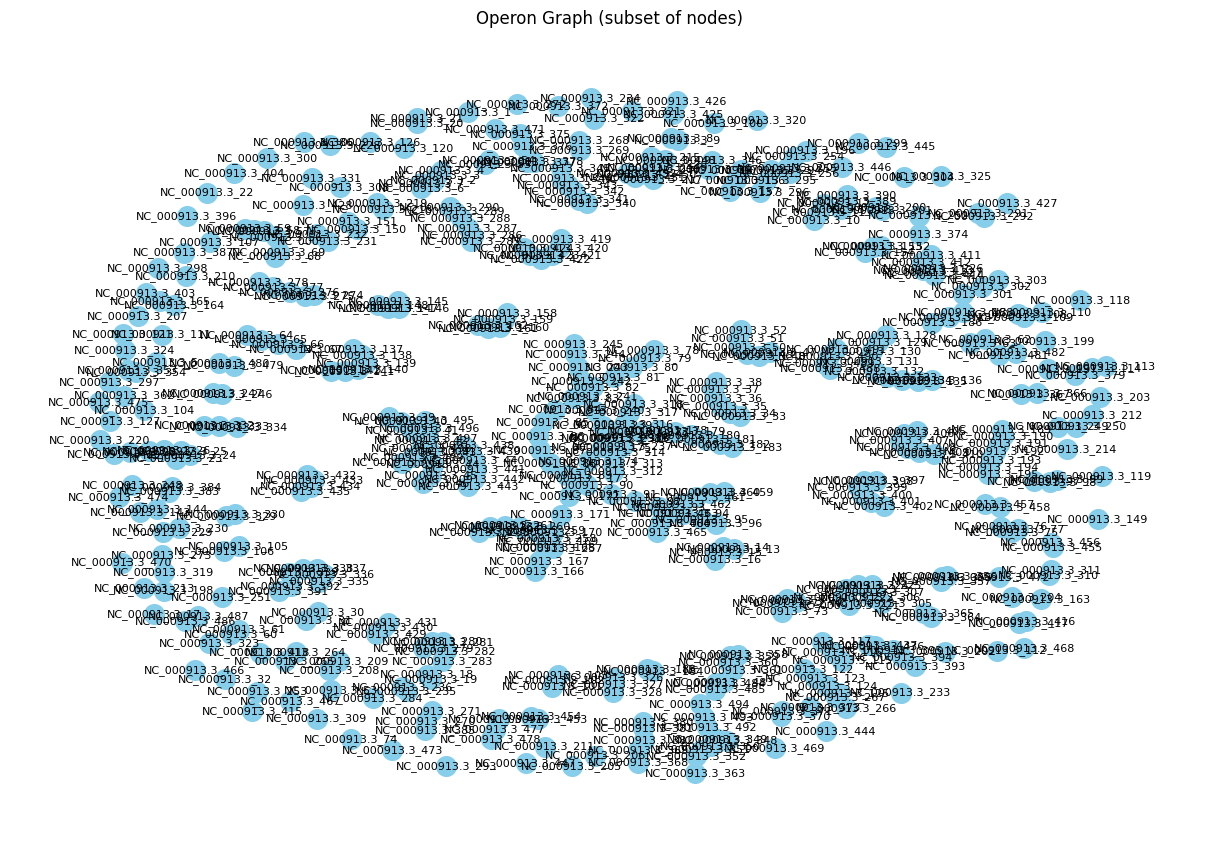

In [26]:
import matplotlib.pyplot as plt
import networkx as nx

file_path = "../data/genomes/ecoli_genome.fna.faa"

# parse genes
genes = parse_prodigal_headers_dict(file_path)

# build graph
G = build_operon_graph(genes, max_distance=200)

# visualize the first 50 nodes for clarity
sub_nodes = list(G.nodes)[:500]
subG = G.subgraph(sub_nodes)

plt.figure(figsize=(12, 8))
pos = nx.spring_layout(subG, seed=42)
nx.draw(subG, pos, with_labels=True, node_size=200, node_color='skyblue', font_size=8)
plt.title("Operon Graph (subset of nodes)")
plt.show()

In [19]:
import pandas as pd
import networkx as nx
from itertools import combinations

# 1. Load PROST data
# prost_df has columns: head, member, score, e_value
# each row means "member" belongs to cluster "head"
# load PROST results (no header, tab-separated)
df = pd.read_csv("/stor/work/Marcotte/project/ivyfan/operon-graph/data/prost_results/ecoli.tsv", sep='\t', header=None)

# assign descriptive column names
df.columns = [
    "head",
    "member",
    "head_name",
    "head_description",
    "species",
    "score",
    "e_value"
]

# clean up whitespace just in case
df = df.map(lambda x: x.strip() if isinstance(x, str) else x)

# select only key columns for now
prost_df = df[["head", "member", "score", "e_value"]].copy()

# 2. Create mapping from gene -> cluster
gene_to_cluster = dict(zip(prost_df["member"], prost_df["head"]))

# 3. Initialize graph 
G = nx.Graph()

# add all cluster heads as nodes
for cluster in prost_df["head"].unique():
    G.add_node(cluster)

# 4. Build edges based on operon adjacency
for i, operon in enumerate(operons, 1):
    # extract gene IDs in this operon
    gene_ids = [g["orf_id"] for g in operon]

    # map to clusters, skipping genes not in PROST mapping
    clusters = [gene_to_cluster[g] for g in gene_ids if g in gene_to_cluster]

    # only keep unique clusters (avoid self-loops)
    clusters = list(set(clusters))

    # add edges between every pair of clusters in this operon
    for c1, c2 in combinations(clusters, 2):
        if G.has_edge(c1, c2):
            G[c1][c2]["weight"] += 1  # strengthen edge if seen again
        else:
            G.add_edge(c1, c2, weight=1, operons=[i])

# summarize
print(f"Total nodes: {G.number_of_nodes()}")
print(f"Total edges: {G.number_of_edges()}")

# Example: show top edges by weight
edges_sorted = sorted(G.edges(data=True), key=lambda x: x[2]["weight"], reverse=True)
for u, v, data in edges_sorted[:10]:
    print(f"{u} -- {v} (weight={data['weight']})")
"""
# Save graph for visualization
nx.write_gml(G, "operon_functional_network.gml")"""

Total nodes: 4403
Total edges: 0


'\n# Save graph for visualization\nnx.write_gml(G, "operon_functional_network.gml")'

In [6]:
gene_to_cluster = dict(zip(prost_df["member"], prost_df["head"]))
list(gene_to_cluster.items())[:10]

[('A5A615', 'C1P615'),
 ('A5A618', 'C1P615'),
 ('G3MTW7', 'C1P615'),
 ('A5A617', 'C1P615'),
 ('Q2EES1', 'C1P615'),
 ('P0DPO1', 'Q6BF87'),
 ('C1P609', 'C1P615'),
 ('C1P5Z8', 'C1P615'),
 ('C1P603', 'C1P615'),
 ('P76239', 'C1P615')]

In [18]:
operons[:10]

[[{'orf_id': 'NC_000913.3_1',
   'contig': 'NC_000913.3',
   'start': 3,
   'end': 98,
   'strand': '+'}],
 [{'orf_id': 'NC_000913.3_2',
   'contig': 'NC_000913.3',
   'start': 337,
   'end': 2799,
   'strand': '+'},
  {'orf_id': 'NC_000913.3_3',
   'contig': 'NC_000913.3',
   'start': 2801,
   'end': 3733,
   'strand': '+'},
  {'orf_id': 'NC_000913.3_4',
   'contig': 'NC_000913.3',
   'start': 3734,
   'end': 5020,
   'strand': '+'}],
 [{'orf_id': 'NC_000913.3_5',
   'contig': 'NC_000913.3',
   'start': 5234,
   'end': 5530,
   'strand': '+'}],
 [{'orf_id': 'NC_000913.3_8',
   'contig': 'NC_000913.3',
   'start': 8238,
   'end': 9191,
   'strand': '+'},
  {'orf_id': 'NC_000913.3_9',
   'contig': 'NC_000913.3',
   'start': 9306,
   'end': 9893,
   'strand': '+'}],
 [{'orf_id': 'NC_000913.3_13',
   'contig': 'NC_000913.3',
   'start': 12163,
   'end': 14079,
   'strand': '+'},
  {'orf_id': 'NC_000913.3_14',
   'contig': 'NC_000913.3',
   'start': 14168,
   'end': 15298,
   'strand': '+'